# Prática

Para atividade prática foi utilizado dados públicos da corrida do grand prix de fórmula 1 de Silverstone em 2026.

Os dados utilizados foram buscadas através da API OpenF1 disponível em \[[14](https://openf1.org/docs/#introduction)].

A documentação da API para acessar as informações utilizadas na atividade estão disponíveis em \[[15](https://openf1.org/docs/#api-endpoints)].

In [1]:
# Imports
from urllib.request import urlopen # Os exemplos disponíveis em [15] para python utilizam o pacote `urllib` 
                                    # para fazer as requisições REST
import json # Utiliza o pacote json para deserializar o conteúdo da requisição 
import numpy as np # Para calcular percentil e outros valores
import pandas as pd # Para montar os DataFrames
import seaborn as sns # Utilzando o seaborn para os gráficos
sns.set() # Para ajustar o design dos gráficos 

## Adiquirindo os dados

In [2]:
# Funções auxiliares 

def get_response(url_path: str):
    '''Função para evitar boiler plate de chamar a requisição e serilizar os dados.'''
    BASE_URL = 'https://api.openf1.org/v1'
    response = urlopen(BASE_URL + url_path)

    return json.loads(response.read().decode('utf-8')) # Serializa a resposta json para dado python lista de dicionários.

def df_response(url_path: str):
    '''Faz a requisição e retorna a resposta em um `DataFrame`'''
    dataframe = pd.DataFrame(get_response(url_path))
    dataframe.to_csv(f'responses_csv{url_path}')
    return dataframe

In [3]:
# Informações do Gran Prix de Silverstone de 2026.

# Filtra o GP de Silverstone pelo ano de 2026 e tipo corrida (Race). 
silverstone_2026 = get_response('/sessions?country_name=United%20Kingdom&session_name=Race&year=2026')[0] 
    # Lista com as informações do filtro encontrado, 

session_key = silverstone_2026['session_key'] # Para saber as informações da sessão eu preciso do indentificador dela.

session_key # 11326

11326

In [4]:
# Informações dos pilotos para poder filtras os dados por pilotos.

# Pilotos no GP de Silverstone
drivers_response = df_response(f'/drivers?session_key={session_key}')

# Apenas as informações que serão utilizadas, cor para mostrar no gráfico e o nome do pilot
drivers = pd.DataFrame(data=drivers_response[['driver_number','last_name', 'team_colour']])

drivers.head()

,driver_number,last_name,team_colour
0,1,Norris,F47600
1,3,Verstappen,4781D7
2,5,Bortoleto,F50537
3,6,Hadjar,4781D7
4,10,Gasly,00A1E8


In [5]:
# Informações das voltas do GP de Silverstone

laps_response = df_response(f'/laps?session_key={session_key}')

laps = laps_response[['driver_number', 'lap_number', 'duration_sector_1', 'duration_sector_2', 'duration_sector_3', 'lap_duration']]
laps = laps.dropna() # Caso algum piloto não completa a volta não tem a duração da volta, por isso limpamos os valores nulos.
laps.head()

,driver_number,lap_number,duration_sector_1,duration_sector_2,duration_sector_3,lap_duration
0,16,1,32.841,38.001,25.919,96.761
1,44,1,33.127,38.368,25.814,97.309
2,12,1,33.637,38.438,25.774,97.849
3,63,1,33.625,38.912,25.976,98.513
4,6,1,34.096,39.212,25.966,99.274


In [6]:
# Informações dos pneus utilizados no GP de Silverstone

stints_response = df_response(f'/stints?session_key={session_key}')

stints = stints_response[['driver_number', 'compound', 'lap_start', 'lap_end', 'tyre_age_at_start']]
stints.head()

,driver_number,compound,lap_start,lap_end,tyre_age_at_start
0,23,MEDIUM,1,1,0
1,81,MEDIUM,1,2,0
2,23,HARD,2,14,0
3,3,MEDIUM,1,17,0
4,27,MEDIUM,1,17,0


## Criando um DataFrame com todas as informações adiquiridas até o momento.

In [7]:
session_data = drivers.merge(right=laps, on='driver_number') # Agora temos as informações dos pilotos e suas voltas

def compound_id(compound):
    '''Apenas para converter a string do tipo do pneu para um numero sendo 
    
    1 - SOFT
    2 - MEDIUM
    3 - HARD 
    4 - INDEFINIDO'''

    if compound == 'SOFT':
        return 1
    elif compound == 'MEDIUM':
        return 2
    elif compound == 'HARD':
        return 3
    else:
        return 4

def stint_per_lap(row, stints_df):
    '''
    Para poder juntar o pneu utilizado (`stints`) com as voltas, temos que criar linhas para o `DataFrame` da sessão (`session_data`) 
    pois os dados dos pneus utilizados (`stints`) não é por volta, e sim pelo intervalo da volta que começou usar o pneu (`lap_start`) 
    até a última volta utilizado(`lap_end`), logo vamos criar os dados do pneu para cada volta assim podemos juntar esse novo `DataFrame`
    utilizando o número do piloto (`driver_number`) e o número da volta (`lap`).
    '''
    driver_number = row['driver_number']
    lap_number = row['lap_number']
    
    lap_stint = stints_df[  (stints['driver_number'] == driver_number) & # Filtra o pneu por piloto e pela volta em que foi usado
                            ( (stints['lap_start'] <= lap_number) & (stints['lap_end'] >= lap_number) ) ]

    tyre_age_at_start = lap_stint['tyre_age_at_start'].iloc[0]
    compound = lap_stint['compound'].iloc[0]
    return { # Dicionário que será transformado em DataFrame para trazer todas as informações necessárias
        'driver_number': driver_number,
        'lap_number': lap_number,
        'compound': compound,
        'tyre_age_at_start': tyre_age_at_start,
        'tyre_age_at_lap': tyre_age_at_start + lap_number - lap_stint['lap_start'].iloc[0], # Vamos utilizar a idade do pneu para
                                                                                            # correlação
                                                                                            # Ela é dada pela a idade inicial do pneu
                                                                                            # + a diferença entre a volta atual do pneu
                                                                                            # com a sua volta inicial 
        'compound_id': compound_id(compound)
    }

stints_per_lap = laps[['driver_number', 'lap_number']]\
                        .apply(stint_per_lap, axis=1, stints_df=stints) # Percorre todas as linhas (`rows`) do DataFrame com axis=1
stints_per_lap = pd.DataFrame(stints_per_lap.to_list()) # Com a informação do pneu por volta podemos ter agora o tipo do pneu 
                                                        # para cada volta da sessão

# Agora basta juntar as informações criadas com as informações da sessão atual
session_data = session_data.merge(right=stints_per_lap, on=['driver_number', 'lap_number'])

session_data.head()

,driver_number,last_name,team_colour,lap_number,duration_sector_1,duration_sector_2,duration_sector_3,lap_duration,compound,tyre_age_at_start,tyre_age_at_lap,compound_id
0,1,Norris,F47600,1,34.960,39.496,26.468,100.924,MEDIUM,0,0,2
1,1,Norris,F47600,2,30.170,38.718,25.948,94.836,MEDIUM,0,1,2
2,1,Norris,F47600,3,30.061,38.936,26.244,95.241,MEDIUM,0,2,2
3,1,Norris,F47600,4,29.899,39.002,26.215,95.116,MEDIUM,0,3,2
4,1,Norris,F47600,5,29.884,38.996,26.274,95.154,MEDIUM,0,4,2


## Análise

### Análise inicial
Plotando os gráficos para entender o que podemos analisar entre a idade do pneu e o tempo de volta.

SOFT compound


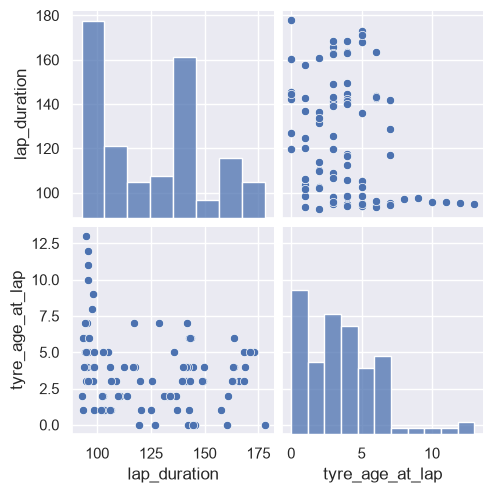

In [8]:
print('SOFT compound')
soft_tyres_session_data = session_data[(session_data['compound_id'] == 1)]
sns.pairplot(soft_tyres_session_data, vars=['lap_duration', 'tyre_age_at_lap'])

MEDIUM compound


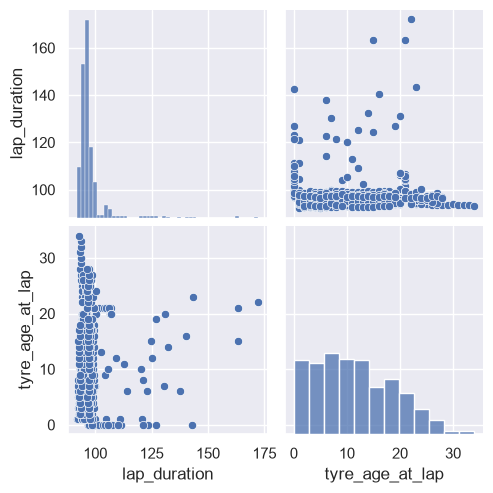

In [9]:
print('MEDIUM compound')
medium_tyres_session_data = session_data[(session_data['compound_id'] == 2)]
sns.pairplot(medium_tyres_session_data, vars=['lap_duration', 'tyre_age_at_lap'])

HARD compound


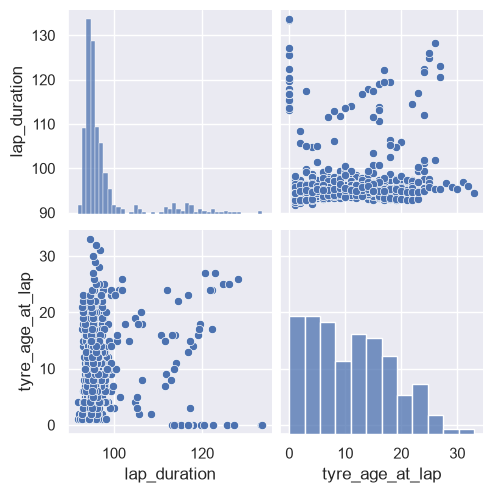

In [10]:
print('HARD compound')
hard_tyres_session_data = session_data[(session_data['compound_id'] == 3)]
sns.pairplot(hard_tyres_session_data, vars=['lap_duration', 'tyre_age_at_lap'])

### Regressão linear para cada tipo de pneu
Tentando indentificar com a linha da regrassão se é mais fácil visualizar alguma correlação.

SOFT Compound


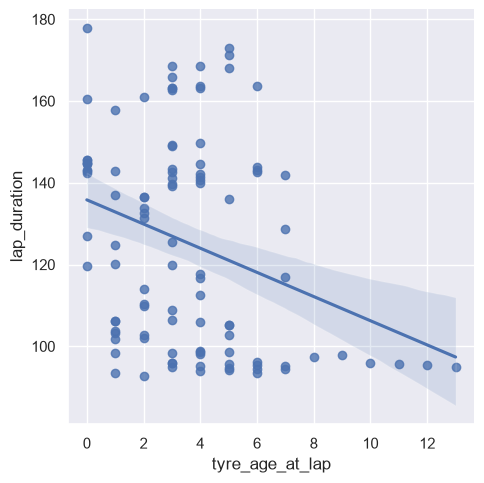

In [11]:
print('SOFT Compound')
sns.lmplot(x='tyre_age_at_lap', y='lap_duration', data=soft_tyres_session_data)

MEDIUM Compound


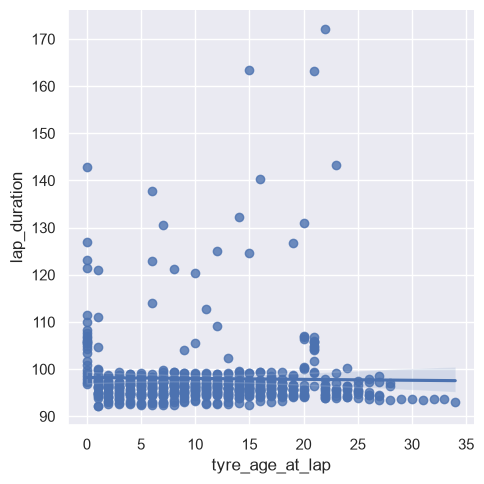

In [12]:
print('MEDIUM Compound')
sns.lmplot(x='tyre_age_at_lap', y='lap_duration', data=medium_tyres_session_data)

HARD Compound


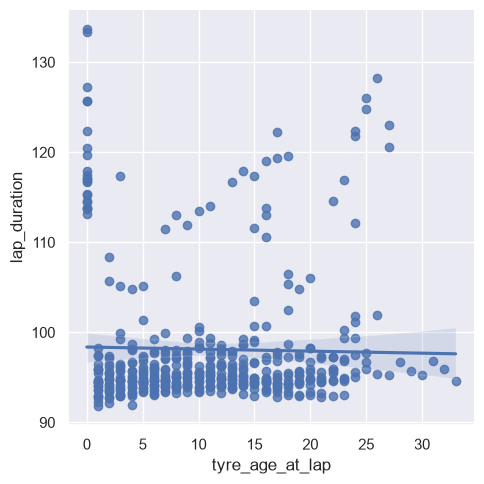

In [13]:
print('HARD Compound') 
sns.lmplot(x='tyre_age_at_lap', y='lap_duration', data=hard_tyres_session_data)

HARD Compound - lap_duration <= 100.000


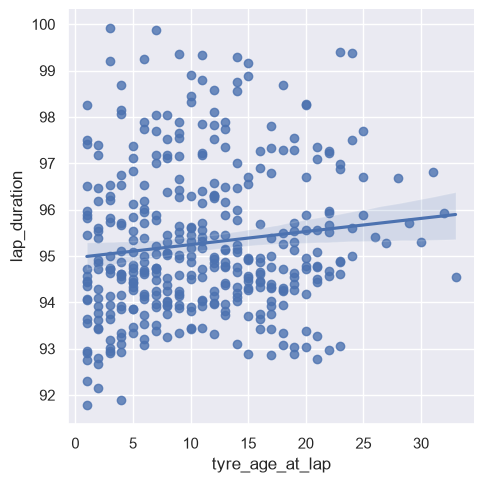

In [14]:
print('HARD Compound - lap_duration <= 100.000') 
sns.lmplot(x='tyre_age_at_lap', y='lap_duration', data=hard_tyres_session_data[hard_tyres_session_data['lap_duration'] <= 100.000])

É Possível notar que temos uma visualização melhor quando limitamos a duração da volta para 100.000 milisegundos.
Vamos ver se isso se repete ao encontrar um valor melhor para a margem vamos filtrar os dados presentes apenas no IQR (que representam a maioria dos valores, evitando valores muito longe do desvio padrão)

### Identificando a duração das voltas (média/mediana) e desvio padrão

Com as informações obtidas no código a baixo podemos observar que há muito mais dados sobres os tipos de pneu `MEDIUM` e `HARD`. 
E para analisar a correlação vamos utilizar até o 3 quartil (75%) dos dados considerado que são valores mais comuns pelo que a 
distribuição mostrou (com exceção dos pneus `SOFT` que possui uma variação muito maior ao observar o desvio padrão. 

In [15]:
def describe(df, title='', column=''):
    '''Reutilizando o código e adicionando mais informações para o describe do numpy juntamente com o displot
    para saber a distribuição'''
    print(title)
    print(df[column].describe())
    print()
    sns.displot(df[column], kde=True)

SOFT Tyres
count    104.000000
mean     125.331462
std       25.519862
min       92.734000
25%       98.673250
50%      125.140000
75%      143.396750
max      177.893000
Name: lap_duration, dtype: float64



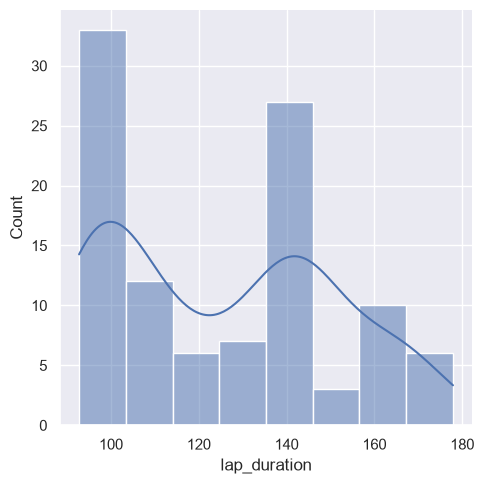

In [16]:
describe(soft_tyres_session_data, title='SOFT Tyres', column='lap_duration')

<Axes: ylabel='lap_duration'>

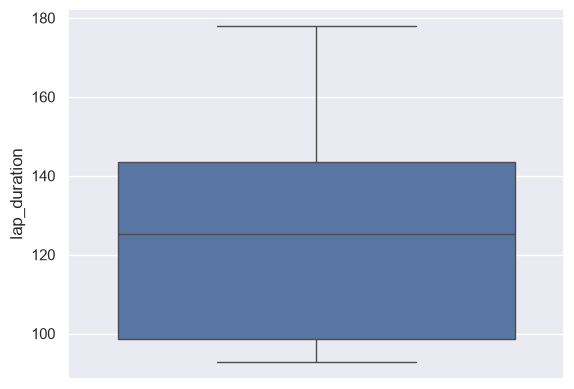

In [17]:
sns.boxplot(soft_tyres_session_data['lap_duration'])

MEDIUM Tyres
count    549.000000
mean      98.003667
std        8.269626
min       92.101000
25%       94.761000
50%       96.162000
75%       97.527000
max      172.150000
Name: lap_duration, dtype: float64



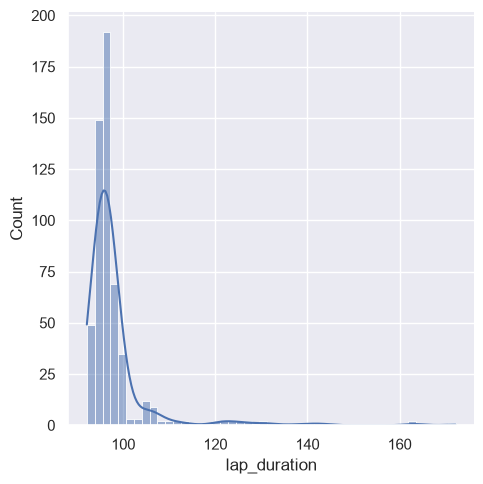

In [18]:
describe(medium_tyres_session_data, title='MEDIUM Tyres', column='lap_duration')

<Axes: ylabel='lap_duration'>

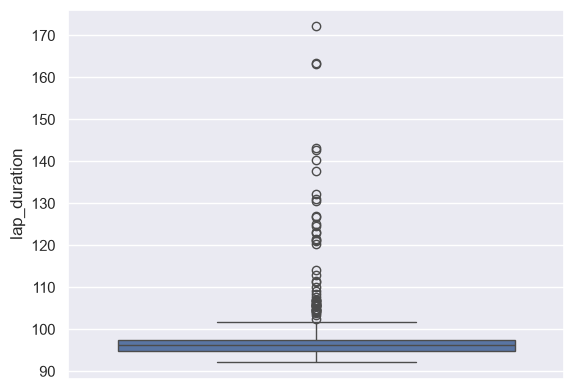

In [19]:
sns.boxplot(medium_tyres_session_data['lap_duration'])

HARD Tyres
count    457.000000
mean      98.120880
std        7.599287
min       91.777000
25%       94.313000
50%       95.303000
75%       97.496000
max      133.694000
Name: lap_duration, dtype: float64



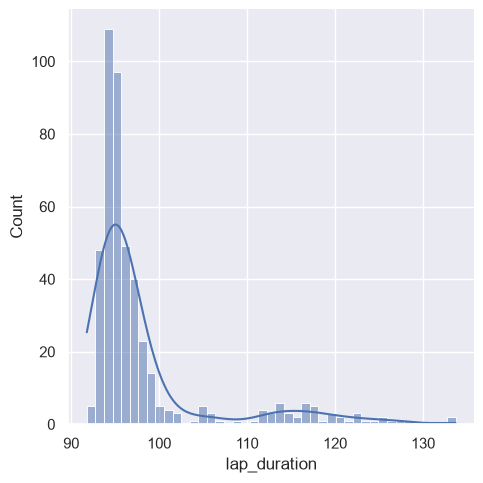

In [20]:
describe(hard_tyres_session_data, title='HARD Tyres', column='lap_duration')

<Axes: ylabel='lap_duration'>

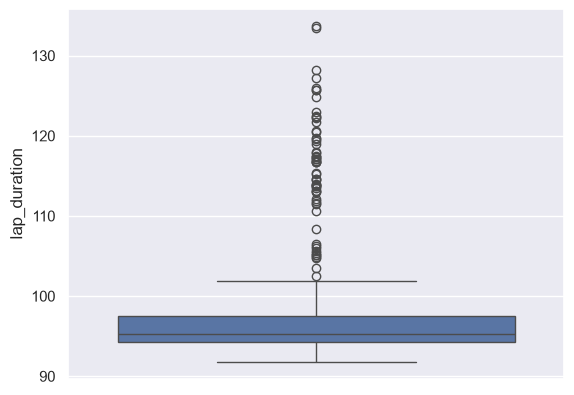

In [21]:
sns.boxplot(hard_tyres_session_data['lap_duration'])

In [22]:
# Novos DataFrame até 3Q (apenas com 75%) dos dados.
def filter_by_percentile(df, column, percentile, debug_print=True): 
    '''Função para filtrar para determinado percentil de determinada coluna
    utilizado para filtrar ate 75th das voltas com base no tempo da volta'''
    column_data = df[column]
    percentile_th = np.percentile(column_data, percentile)
    q_df = df[ column_data <= percentile_th]

    if debug_print: # Informações apenas para conferir se o filtro está correto.
        print(f'population max : {column_data.max()}')
        print(f'population {percentile}th : {percentile_th}')
        print(f'sample max : {q_df[column].max()}')
    
    return df 

In [23]:
soft_tyres_session_data_75th = filter_by_percentile(soft_tyres_session_data, column='lap_duration', percentile=75)

population max : 177.893
population 75th : 143.39675
sample max : 143.272


In [24]:
medium_tyres_session_data_75th = filter_by_percentile(medium_tyres_session_data, column='lap_duration', percentile=75)

population max : 172.15
population 75th : 97.527
sample max : 97.527


In [25]:
hard_tyres_session_data_75th = filter_by_percentile(hard_tyres_session_data, column='lap_duration', percentile=75)

population max : 133.694
population 75th : 97.496
sample max : 97.496


## Nova análise agora com os dados filtrados utilizando a regressão linear no _scatter plot_ novamente

Agora vamos verificar o resultado de considerar apenas 75th percentil.

Podemos notar uma pequena correlação inversa para pneus macios (`SOFT`), ou seja, quanto maior a idade do pneu menor o tempo da volta 
(mais rápida é a volta). 

Já nos outros não houve correlação por ter um valor próximo a 0.

In [26]:
def correlacao(x, y, df, title):
    '''Uma nova função para mostrar o gráfico e os valores da correlacao (valores entre 1 e -1)'''
    print(title)
    print(f'Covariância : {np.corrcoef(df[x], df[y])[0,1]}')
    sns.lmplot(x=x, y=y, data=df)

SOFT Tyre
Covariância : -0.3033478130908021


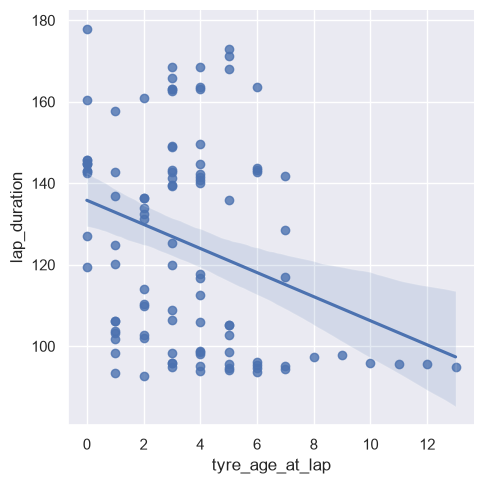

In [27]:
correlacao(title='SOFT Tyre', x='tyre_age_at_lap', y='lap_duration', df=soft_tyres_session_data_75th)

MEDIUM Tyre
Covariância : -0.017509720992438766


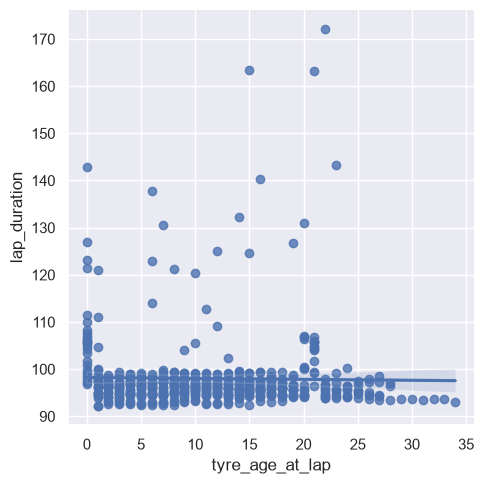

In [28]:
correlacao(title='MEDIUM Tyre', x='tyre_age_at_lap', y='lap_duration', df=medium_tyres_session_data_75th)

HARD Tyre
Covariância : -0.022210669496579093


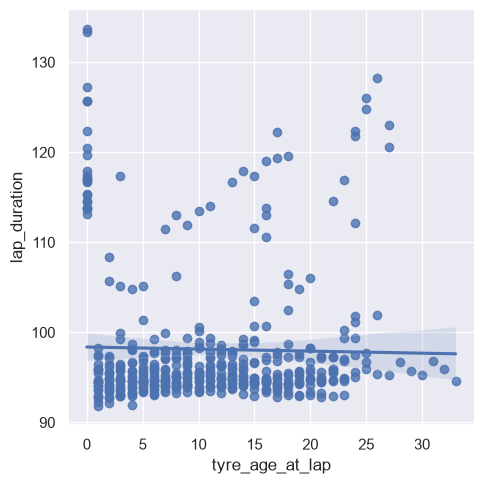

In [29]:
correlacao(title='HARD Tyre', x='tyre_age_at_lap', y='lap_duration', df=hard_tyres_session_data_75th)

### Análise com os valores totais já que temos os valores


Primeiro analisando com todo o _dataset_.

SOFT Tyre
Covariância : -0.3033478130908021


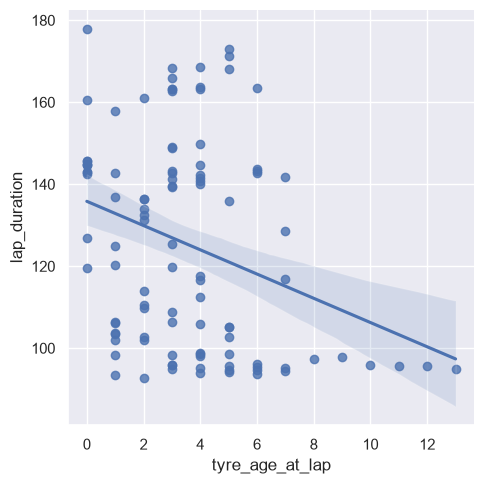

In [30]:
correlacao(title='SOFT Tyre', x='tyre_age_at_lap', y='lap_duration', df=soft_tyres_session_data)

MEDIUM Tyre
Covariância : -0.017509720992438766


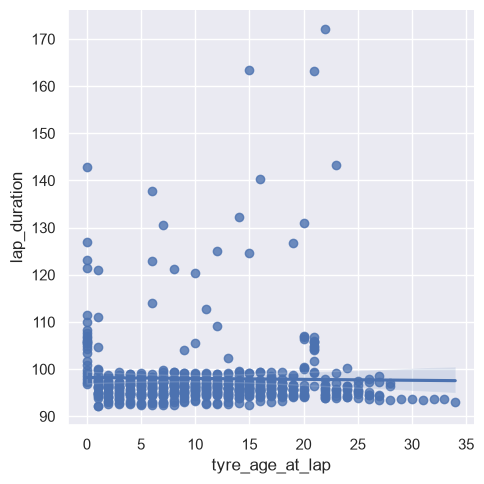

In [31]:
correlacao(title='MEDIUM Tyre', x='tyre_age_at_lap', y='lap_duration', df=medium_tyres_session_data)

HARD Tyre
Covariância : -0.022210669496579093


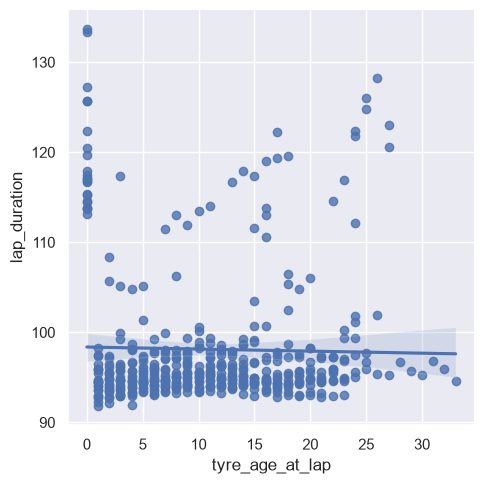

In [32]:
correlacao(title='HARD Tyre', x='tyre_age_at_lap', y='lap_duration', df=hard_tyres_session_data)

Agora analisando com voltas menors que 100,000 milisegundos.

SOFT Tyre
Covariância : -0.027030618539952162


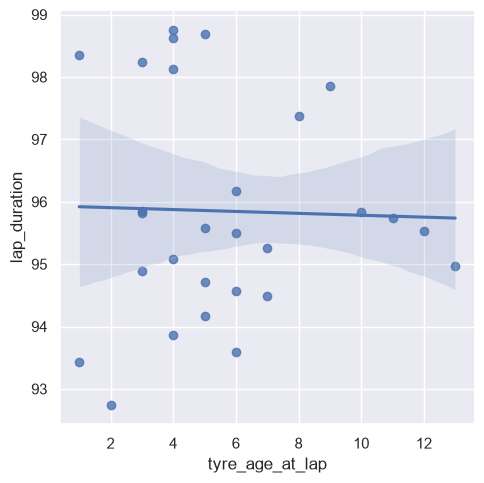

In [33]:
correlacao(title='SOFT Tyre', x='tyre_age_at_lap', y='lap_duration', 
           df=soft_tyres_session_data[soft_tyres_session_data['lap_duration'] <= 100.000])

MEDIUM Tyre
Covariância : -0.0878714235093707


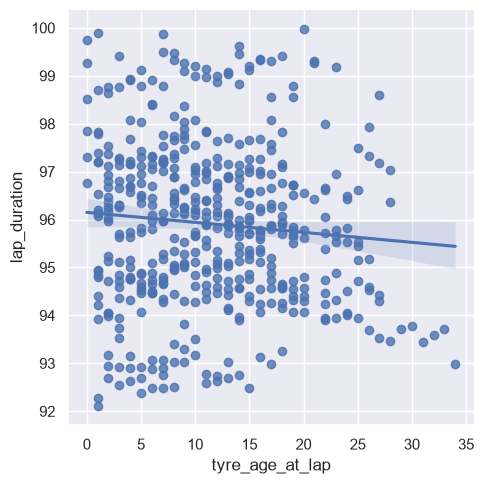

In [34]:
correlacao(title='MEDIUM Tyre', x='tyre_age_at_lap', y='lap_duration', 
           df=medium_tyres_session_data[medium_tyres_session_data['lap_duration'] <= 100.000])

MEDIUM Tyre
Covariância : 0.12237869613490619


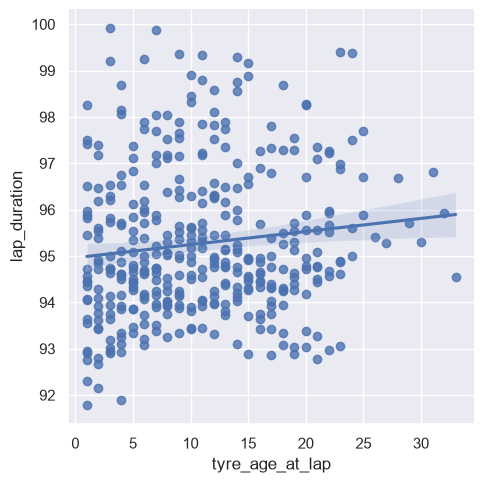

In [35]:
correlacao(title='MEDIUM Tyre', x='tyre_age_at_lap', y='lap_duration', 
           df=hard_tyres_session_data[hard_tyres_session_data['lap_duration'] <= 100.000])

Como resultado temos:

Utilizando **75th perncetil** da amostra:
- Pneu _SOFT_: Pode haver uma pequena correlação que talvez vale a investigação.
- Pneu _MEDIUM_: Não há correlação.
- Pneu _HARD_: Não há correlação.


Utilizando **todos os dados** da amostra:
- Pneu _SOFT_: Pode haver uma pequena correlação que talvez vale a investigação.
- Pneu _MEDIUM_: Não há correlação.
- Pneu _HARD_: Não há correlação.

Utilizando **voltas até 100.000 milisegundos** da amostra:
- Pneu _SOFT_:  Não há correlação.
- Pneu _MEDIUM_: Não há correlação.
- Pneu _HARD_: Resultado muito pequeno (~0.12) para indicar correlação.